# HW10-11 - Computer Vision in PyTorch (S10+S11)

Практическая работа 10-11 - Атаманчук А.В. КВБО-01-22

Часть A (classification): C1, C2, C3, C4
Часть B (segmentation): V1, V2
Сохранение в artifacts/

Трек во второй части: segmentation (датасет `OxfordIIITPet`).

In [1]:
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights, deeplabv3_resnet50

ROOT_DIR = Path.cwd()
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = ROOT_DIR / "data"
RUNS_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_classifier.pt"
BEST_CFG_PATH = ARTIFACTS_DIR / "best_classifier_config.json"

SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 0

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


set_seed(SEED)
DEVICE = get_device()
print("seed:", SEED)
print("device:", DEVICE)


seed: 42
device: cuda


## A) Данные и sanity-check

classification batch shapes: (128, 3, 96, 96) (128,)


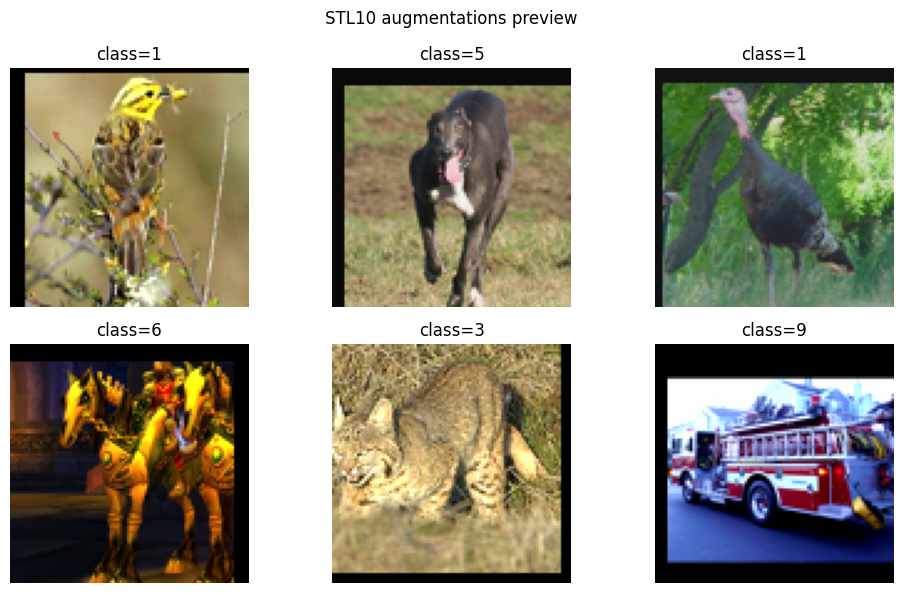

In [2]:
class STL10TransformedSubset(Dataset):
    def __init__(self, base_dataset: datasets.STL10, indices, transform: Callable):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        return self.transform(image), label


stl_train_raw = datasets.STL10(root=str(DATA_DIR), split="train", download=True)
stl_test_raw = datasets.STL10(root=str(DATA_DIR), split="test", download=True)

num_classes = len(stl_train_raw.classes)
mean = [0.4467, 0.4398, 0.4066]
std = [0.2603, 0.2566, 0.2713]

tf_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

tf_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

tf_resnet = ResNet18_Weights.DEFAULT.transforms()

train_len = int(0.8 * len(stl_train_raw))
val_len = len(stl_train_raw) - train_len
split_gen = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(stl_train_raw, [train_len, val_len], generator=split_gen)
train_idx, val_idx = list(train_subset.indices), list(val_subset.indices)

c1_train = STL10TransformedSubset(stl_train_raw, train_idx, tf_base)
c2_train = STL10TransformedSubset(stl_train_raw, train_idx, tf_aug)
c_val_base = STL10TransformedSubset(stl_train_raw, val_idx, tf_base)
c_val_resnet = STL10TransformedSubset(stl_train_raw, val_idx, tf_resnet)
c_train_resnet = STL10TransformedSubset(stl_train_raw, train_idx, tf_resnet)

test_base = STL10TransformedSubset(stl_test_raw, list(range(len(stl_test_raw))), tf_base)
test_resnet = STL10TransformedSubset(stl_test_raw, list(range(len(stl_test_raw))), tf_resnet)

pin = DEVICE.type == "cuda"
c1_train_loader = DataLoader(c1_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin)
c2_train_loader = DataLoader(c2_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin)
c_val_loader_base = DataLoader(c_val_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
c_val_loader_resnet = DataLoader(c_val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
c_train_loader_resnet = DataLoader(c_train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin)
c_test_loader_base = DataLoader(test_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
c_test_loader_resnet = DataLoader(test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

xb, yb = next(iter(c1_train_loader))
print("classification batch shapes:", tuple(xb.shape), tuple(yb.shape))

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("STL10 augmentations preview", fontsize=12)
for i, ax in enumerate(axes.flat):
    img, lbl = stl_train_raw[i]
    aug = tf_aug(img)
    aug_np = aug.permute(1, 2, 0).numpy()
    aug_np = np.clip(aug_np * np.array(std) + np.array(mean), 0.0, 1.0)
    ax.imshow(aug_np)
    ax.set_title(f"class={lbl}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150)
plt.show()

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18_head_only(n_classes: int) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def build_resnet18_finetune(n_classes: int) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    for p in model.fc.parameters():
        p.requires_grad = True
    return model


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


@dataclass
class ExpResult:
    experiment_id: str
    notes: str
    lr: float
    epochs: int
    best_val_accuracy: float
    best_state: dict
    history: dict


def run_exp(experiment_id, model_builder, train_loader, val_loader, epochs, lr, notes):
    set_seed(SEED)
    model = model_builder().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val, best_state = -1.0, None

    for _ in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return ExpResult(experiment_id, notes, lr, epochs, float(best_val), best_state, history)

Best classification run: C4 val_acc= 0.947
Final test accuracy (single pass): 0.947


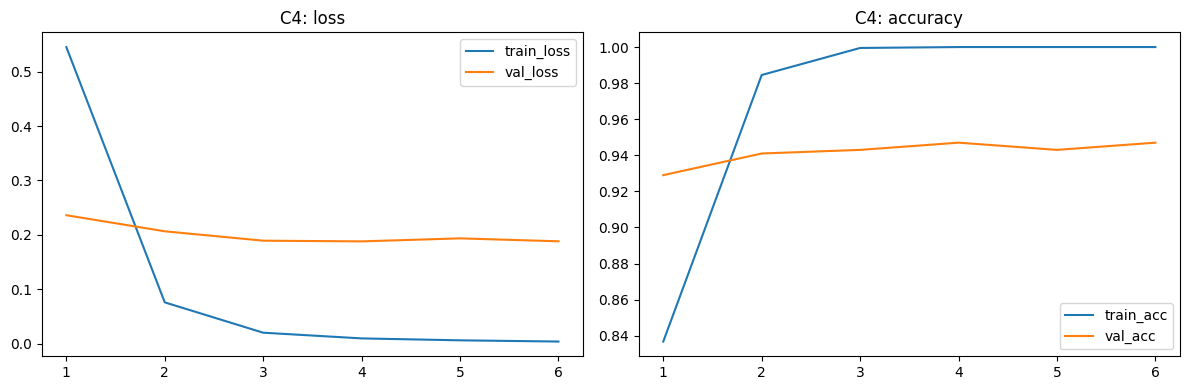

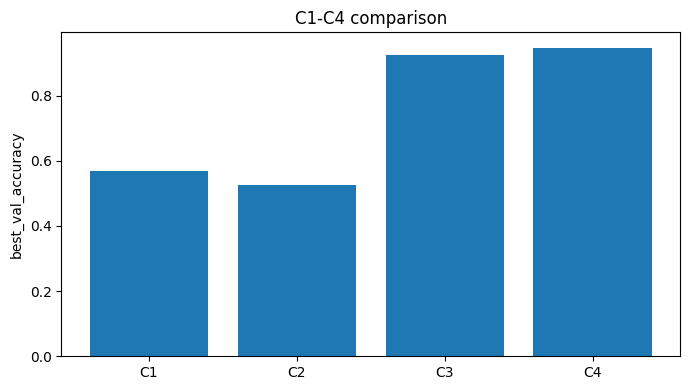

In [4]:
# C1-C4
c1 = run_exp(
    "C1",
    lambda: SimpleCNN(num_classes),
    c1_train_loader,
    c_val_loader_base,
    epochs=6,
    lr=1e-3,
    notes="simple-cnn-base (no augmentations)",
)

c2 = run_exp(
    "C2",
    lambda: SimpleCNN(num_classes),
    c2_train_loader,
    c_val_loader_base,
    epochs=6,
    lr=1e-3,
    notes="simple-cnn-aug (same architecture + augmentations)",
)

c3 = run_exp(
    "C3",
    lambda: build_resnet18_head_only(num_classes),
    c_train_loader_resnet,
    c_val_loader_resnet,
    epochs=6,
    lr=1e-3,
    notes="resnet18-head-only (frozen backbone)",
)

c4 = run_exp(
    "C4",
    lambda: build_resnet18_finetune(num_classes),
    c_train_loader_resnet,
    c_val_loader_resnet,
    epochs=6,
    lr=2e-4,
    notes="resnet18-finetune (layer4 + fc trainable)",
)

all_cls = [c1, c2, c3, c4]
best = max(all_cls, key=lambda x: x.best_val_accuracy)
print("Best classification run:", best.experiment_id, "val_acc=", round(best.best_val_accuracy, 4))

torch.save(best.best_state, BEST_MODEL_PATH)

best_cfg = {
    "dataset": "STL10",
    "seed": SEED,
    "best_experiment_id": best.experiment_id,
    "model": best.notes,
    "batch_size": BATCH_SIZE,
    "epochs": best.epochs,
    "optimizer": "Adam",
    "lr": best.lr,
    "transforms": {
        "base": "ToTensor + Normalize(STL10 stats)",
        "aug": "RandomHorizontalFlip + RandomCrop + ColorJitter + Normalize",
        "resnet": "ResNet18_Weights.DEFAULT.transforms()",
    },
}
BEST_CFG_PATH.write_text(json.dumps(best_cfg, indent=2, ensure_ascii=False), encoding="utf-8")

criterion = nn.CrossEntropyLoss()
if best.experiment_id in {"C1", "C2"}:
    model = SimpleCNN(num_classes).to(DEVICE)
    model.load_state_dict(best.best_state)
    _, test_acc = evaluate(model, c_test_loader_base, criterion, DEVICE)
elif best.experiment_id == "C3":
    model = build_resnet18_head_only(num_classes).to(DEVICE)
    model.load_state_dict(best.best_state)
    _, test_acc = evaluate(model, c_test_loader_resnet, criterion, DEVICE)
else:
    model = build_resnet18_finetune(num_classes).to(DEVICE)
    model.load_state_dict(best.best_state)
    _, test_acc = evaluate(model, c_test_loader_resnet, criterion, DEVICE)

print("Final test accuracy (single pass):", round(float(test_acc), 4))

rows = []
for exp in all_cls:
    rows.append(
        {
            "experiment_id": exp.experiment_id,
            "task": "classification",
            "dataset": "STL10",
            "seed": SEED,
            "model_summary": exp.notes,
            "optimizer": "Adam",
            "lr": exp.lr,
            "epochs_trained": exp.epochs,
            "best_val_accuracy": exp.best_val_accuracy,
            "test_accuracy": float(test_acc) if exp.experiment_id == best.experiment_id else "",
            "precision": "",
            "recall": "",
            "mean_iou": "",
            "notes": exp.notes,
        }
    )

# Curves for best run
epochs_x = list(range(1, len(best.history["train_loss"]) + 1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs_x, best.history["train_loss"], label="train_loss")
ax[0].plot(epochs_x, best.history["val_loss"], label="val_loss")
ax[0].set_title(f"{best.experiment_id}: loss")
ax[0].legend()
ax[1].plot(epochs_x, best.history["train_acc"], label="train_acc")
ax[1].plot(epochs_x, best.history["val_acc"], label="val_acc")
ax[1].set_title(f"{best.experiment_id}: accuracy")
ax[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150)
plt.show()

# C1-C4 compare
ids = [r["experiment_id"] for r in rows if r["task"] == "classification"]
vals = [float(r["best_val_accuracy"]) for r in rows if r["task"] == "classification"]
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.bar(ids, vals)
ax2.set_ylabel("best_val_accuracy")
ax2.set_title("C1-C4 comparison")
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "classification_compare.png", dpi=150)
plt.show()

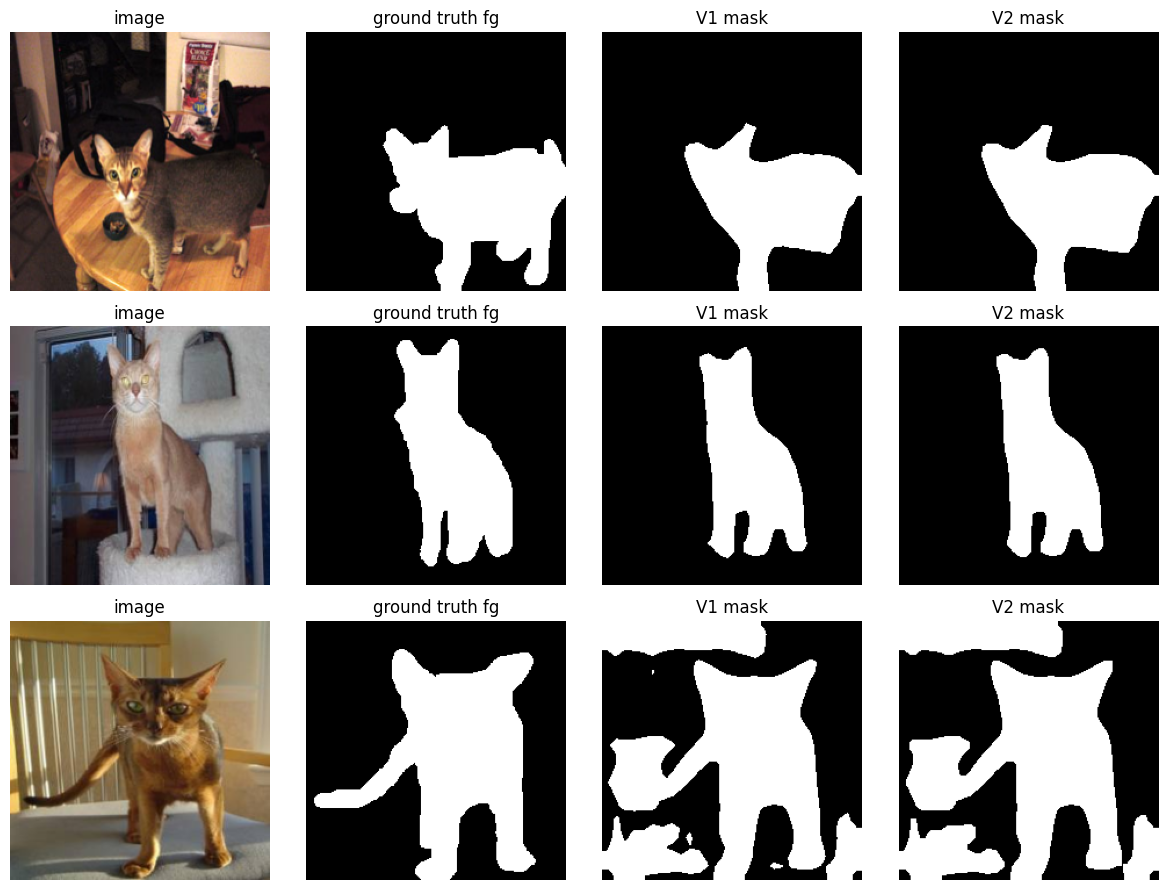

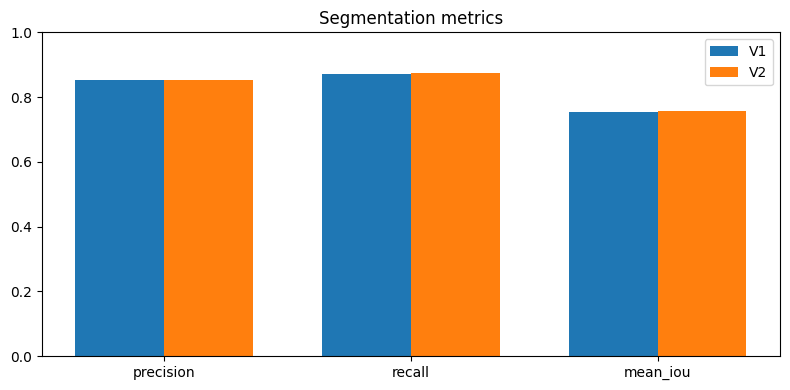

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base (no augmentations),Adam,0.001,6,0.569,,,,,simple-cnn-base (no augmentations)
1,C2,classification,STL10,42,simple-cnn-aug (same architecture + augmentati...,Adam,0.001,6,0.527,,,,,simple-cnn-aug (same architecture + augmentati...
2,C3,classification,STL10,42,resnet18-head-only (frozen backbone),Adam,0.001,6,0.925,,,,,resnet18-head-only (frozen backbone)
3,C4,classification,STL10,42,resnet18-finetune (layer4 + fc trainable),Adam,0.0002,6,0.947,0.947,,,,resnet18-finetune (layer4 + fc trainable)
4,V1,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50 pretrained (COCO), foregrou...",,,0,,,0.853657,0.872,0.755088,V1: raw foreground mask
5,V2,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50 pretrained (COCO), foregrou...",,,0,,,0.854035,0.872993,0.755756,V2: morphological cleanup (close-open)


In [5]:
class PetTransform:
    def __init__(self, image_size: int = 224):
        self.image_tf = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.mask_resize = transforms.Resize((image_size, image_size), interpolation=Image.NEAREST)

    def __call__(self, image, mask):
        image_t = self.image_tf(image)
        mask_r = self.mask_resize(mask)
        mask_np = np.array(mask_r, dtype=np.uint8)
        return image_t, mask_np


def mask_metrics(pred, gt):
    pred_b = pred.astype(bool)
    gt_b = gt.astype(bool)
    tp = np.logical_and(pred_b, gt_b).sum()
    fp = np.logical_and(pred_b, np.logical_not(gt_b)).sum()
    fn = np.logical_and(np.logical_not(pred_b), gt_b).sum()
    union = np.logical_or(pred_b, gt_b).sum()
    precision = float(tp / (tp + fp + 1e-9))
    recall = float(tp / (tp + fn + 1e-9))
    iou = float(tp / (union + 1e-9))
    return precision, recall, iou


def postprocess_v2(mask, kernel_size: int = 5):
    t = torch.from_numpy(mask.astype(np.float32))[None, None]
    dil = F.max_pool2d(t, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    ero = -F.max_pool2d(-dil, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    ero2 = -F.max_pool2d(-ero, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    dil2 = F.max_pool2d(ero2, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    return (dil2[0, 0].numpy() > 0.5).astype(np.uint8)


pet_tf = PetTransform(image_size=224)
pet_ds = datasets.OxfordIIITPet(
    root=str(DATA_DIR),
    split="test",
    target_types="segmentation",
    download=True,
    transforms=pet_tf,
)
pet_loader = DataLoader(pet_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT).to(DEVICE)
seg_model.eval()

p1_list, r1_list, i1_list = [], [], []
p2_list, r2_list, i2_list = [], [], []
vis = []

with torch.no_grad():
    for i, (xb, mask_np) in enumerate(pet_loader):
        if i >= 40:
            break
        xb = xb.to(DEVICE)
        logits = seg_model(xb)["out"][0]
        pred_cls = logits.argmax(dim=0).cpu().numpy().astype(np.uint8)

        if isinstance(mask_np, torch.Tensor):
            mask_arr = mask_np[0].detach().cpu().numpy()
        else:
            mask_arr = np.asarray(mask_np[0])

        gt = (mask_arr != 2).astype(np.uint8)
        pred_v1 = (pred_cls != 0).astype(np.uint8)
        pred_v2 = postprocess_v2(pred_v1, kernel_size=5)

        p1, r1, iou1 = mask_metrics(pred_v1, gt)
        p2, r2, iou2 = mask_metrics(pred_v2, gt)
        p1_list.append(p1)
        r1_list.append(r1)
        i1_list.append(iou1)
        p2_list.append(p2)
        r2_list.append(r2)
        i2_list.append(iou2)

        if len(vis) < 3:
            img_np = xb[0].cpu().permute(1, 2, 0).numpy()
            img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0.0, 1.0)
            vis.append((img_np, gt, pred_v1, pred_v2))

metrics_v1 = {
    "precision": float(np.mean(p1_list)),
    "recall": float(np.mean(r1_list)),
    "mean_iou": float(np.mean(i1_list)),
}
metrics_v2 = {
    "precision": float(np.mean(p2_list)),
    "recall": float(np.mean(r2_list)),
    "mean_iou": float(np.mean(i2_list)),
}

# examples figure
fig, axes = plt.subplots(len(vis), 4, figsize=(12, 3 * len(vis)))
if len(vis) == 1:
    axes = np.expand_dims(axes, axis=0)
for row, (img_np, gt, v1, v2) in enumerate(vis):
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title("image")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("ground truth fg")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(v1, cmap="gray")
    axes[row, 2].set_title("V1 mask")
    axes[row, 2].axis("off")
    axes[row, 3].imshow(v2, cmap="gray")
    axes[row, 3].set_title("V2 mask")
    axes[row, 3].axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=150)
plt.show()

# metrics figure
labels = ["precision", "recall", "mean_iou"]
v1_vals = [metrics_v1[k] for k in labels]
v2_vals = [metrics_v2[k] for k in labels]
x = np.arange(len(labels))
width = 0.36
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(x - width / 2, v1_vals, width, label="V1")
ax2.bar(x + width / 2, v2_vals, width, label="V2")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1)
ax2.set_title("Segmentation metrics")
ax2.legend()
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150)
plt.show()

rows.append(
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained (COCO), foreground=pred!=0",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": metrics_v1["precision"],
        "recall": metrics_v1["recall"],
        "mean_iou": metrics_v1["mean_iou"],
        "notes": "V1: raw foreground mask",
    }
)
rows.append(
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained (COCO), foreground=pred!=0",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": metrics_v2["precision"],
        "recall": metrics_v2["recall"],
        "mean_iou": metrics_v2["mean_iou"],
        "notes": "V2: morphological cleanup (close-open)",
    }
)

columns_order = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

runs_df = pd.DataFrame(rows)[columns_order]
runs_df.to_csv(RUNS_PATH, index=False)
runs_df